**Lifetime Value (LTV) Project**

This notebook focuses on forecasting Customer Lifetime Value (LTV) using historical transaction data. The dataset is transformed into time series sequences to capture temporal patterns and customer behavior over time.

Two forecasting approaches are explored:

*   Long Short-Term Memory (LSTM), a recurrent neural network designed for sequential data,
*   TimeFM, a foundation model for time series forecasting.

Their performance is evaluated to assess their effectiveness in projecting future customer value.

## Setup and Dependencies

### Library

Imports the libraries and dependencies required throughout the project.

In [593]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.colab import drive

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Auth

Authentication to google account and drive for more google cloud services access

In [594]:
drive.mount('/content/drive')

auth.authenticate_user()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preparation

### Loader

Query for access data in Google BigQuery

In [ ]:
# cohort30 = linkit-rnd-475909.country_summary.ml_lstm_training_30cohorts
# cohort50 = linkit-rnd-475909.country_summary.ml_lstm_50cohorts_5adnets

project_id = 'linkit-rnd-475909'
SEED_DAYS = 7

sql_query = """
SELECT *
FROM linkit-rnd-475909.country_summary.ml_lstm_50cohorts_5adnets
ORDER BY date_created_at, date_update ASC;
"""

# unseen_query = """
# SELECT *
# FROM `linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts`
# """


Load data from bigquery

In [479]:
df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')
df.head()

/tmp/ipykernel_5229/3670017302.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')


,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0


In [480]:
df.tail()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
16073,2025-12-05,MDEA,2026-06-02,7,14000.0,DAILYPUSH,714000.0
16074,2025-12-05,MBP,2026-06-02,3,6000.0,DAILYPUSH,584000.0
16075,2025-12-05,MDEA,2026-06-03,2,4000.0,DAILYPUSH,718000.0
16076,2025-12-05,MBP,2026-06-05,0,0.0,PURGE,584000.0
16077,2025-12-05,MDEA,2026-06-05,0,0.0,PURGE,718000.0


### Exploration

Compact information about data

In [481]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16078 entries, 0 to 16077
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        16078 non-null  dbdate 
 1   adnet                  16078 non-null  object 
 2   date_update            16078 non-null  dbdate 
 3   no_of_user             16078 non-null  Int64  
 4   revenue_dailypush      16078 non-null  float64
 5   subject                16078 non-null  object 
 6   revenue_running_total  16078 non-null  float64
dtypes: Int64(1), dbdate(2), float64(2), object(2)
memory usage: 895.1+ KB


Checking unique value

In [482]:
unique_values = df.nunique()
print(unique_values)

date_created_at            42
adnet                       5
date_update               425
no_of_user                435
revenue_dailypush         368
subject                     3
revenue_running_total    5248
dtype: int64


Checking cohort list

In [483]:
sorted(df['date_created_at'].unique())

[datetime.date(2025, 1, 1),
 datetime.date(2025, 1, 7),
 datetime.date(2025, 1, 10),
 datetime.date(2025, 1, 14),
 datetime.date(2025, 1, 20),
 datetime.date(2025, 1, 21),
 datetime.date(2025, 1, 23),
 datetime.date(2025, 1, 28),
 datetime.date(2025, 1, 30),
 datetime.date(2025, 2, 3),
 datetime.date(2025, 2, 8),
 datetime.date(2025, 2, 9),
 datetime.date(2025, 2, 10),
 datetime.date(2025, 2, 14),
 datetime.date(2025, 2, 17),
 datetime.date(2025, 3, 8),
 datetime.date(2025, 3, 26),
 datetime.date(2025, 3, 27),
 datetime.date(2025, 3, 30),
 datetime.date(2025, 4, 21),
 datetime.date(2025, 5, 13),
 datetime.date(2025, 6, 3),
 datetime.date(2025, 6, 24),
 datetime.date(2025, 7, 13),
 datetime.date(2025, 7, 15),
 datetime.date(2025, 7, 18),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 30),
 datetime.date(2025, 9, 2),
 datetime.date(2025, 9, 7),
 datetime.date(2025, 9, 11),
 datetime.date(2025, 9, 17),
 datetime.date(2025, 10, 2),
 datetime.date(2025, 10, 17),
 datetime.date(2025, 10

Checking duplicate data

In [484]:
df.duplicated().sum()

np.int64(0)

### Unseen Data

Preparation for unseen data, around 5% from total data 

In [485]:
all_cohorts = sorted(df["date_created_at"].unique())
test_size = max(1, int(len(all_cohorts) * 0.1))
unseen_cohorts = all_cohorts[-test_size:]
development_cohorts = all_cohorts[:-test_size]

development_df = df[
    df["date_created_at"].isin(development_cohorts)
].copy()

unseen_raw = df[
    df["date_created_at"].isin(unseen_cohorts)
].copy()

Insert to pandas for next step

In [486]:
development_df = df[
    df["date_created_at"].isin(development_cohorts)
].copy()

unseen_raw = df[
    df["date_created_at"].isin(unseen_cohorts)
].copy()

Checking total cohorts unseen

In [487]:
print("Total Cohorts Unseen:", unseen_raw["date_created_at"].nunique())
print("")
print("Total Adnets:", unseen_raw["adnet"].nunique())
print(unseen_raw["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", unseen_raw.groupby("adnet")["date_created_at"].nunique())

Total Cohorts Unseen: 4

Total Adnets: 2
['MBP' 'MDEA']

Total Cohorts per Adnet: adnet
MBP     4
MDEA    4
Name: date_created_at, dtype: int64


### Feature Engineering

Adding cohort age (date update - date created) for getting information day every cohort

In [488]:
df['cohort_age'] = (
    df['date_update'] -
    df['date_created_at']
).dt.days

In [489]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1


Adding day of week using pandas format (Monday is starting from 0), weekend flag (1 if Saturday/Sunday), and day of month

In [490]:
df['date_created_at'] = pd.to_datetime(df['date_created_at'])
df['date_update'] = pd.to_datetime(df['date_update'])

df['day_of_week'] = df['date_update'].dt.dayofweek
df['weekend'] = (df['date_update'].dt.dayofweek >= 5).astype(int)
df['day_of_month'] = df['date_update'].dt.day

In [491]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0,2,0,1
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,0,1
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0,2,0,1
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0,2,0,1
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1,3,0,2


Checking data information

In [492]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16078 entries, 0 to 16077
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        16078 non-null  datetime64[ns]
 1   adnet                  16078 non-null  object        
 2   date_update            16078 non-null  datetime64[ns]
 3   no_of_user             16078 non-null  Int64         
 4   revenue_dailypush      16078 non-null  float64       
 5   subject                16078 non-null  object        
 6   revenue_running_total  16078 non-null  float64       
 7   cohort_age             16078 non-null  int64         
 8   day_of_week            16078 non-null  int32         
 9   weekend                16078 non-null  int64         
 10  day_of_month           16078 non-null  int32         
dtypes: Int64(1), datetime64[ns](2), float64(2), int32(2), int64(2), object(2)
memory usage: 1.2+ MB


### Visualization

Distribution of cohort length

In [493]:
cohort_length = (
    df.groupby('date_created_at')['cohort_age']
      .max()
      .add(1)
      .reset_index(name='cohort_length')
)

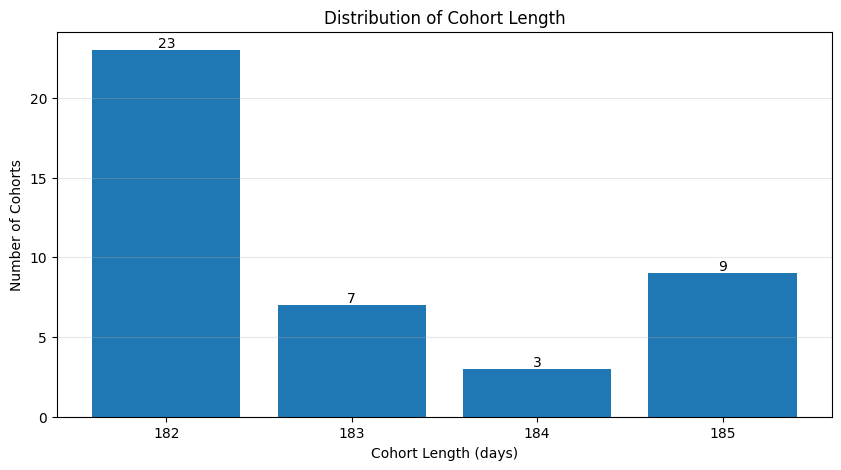

In [494]:
dist = (
    cohort_length['cohort_length']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    dist.index.astype(str),
    dist.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xlabel('Cohort Length (days)')
plt.ylabel('Number of Cohorts')
plt.title('Distribution of Cohort Length')
plt.grid(axis='y', alpha=0.3)

plt.show()

Distribution of running revenue per cohort

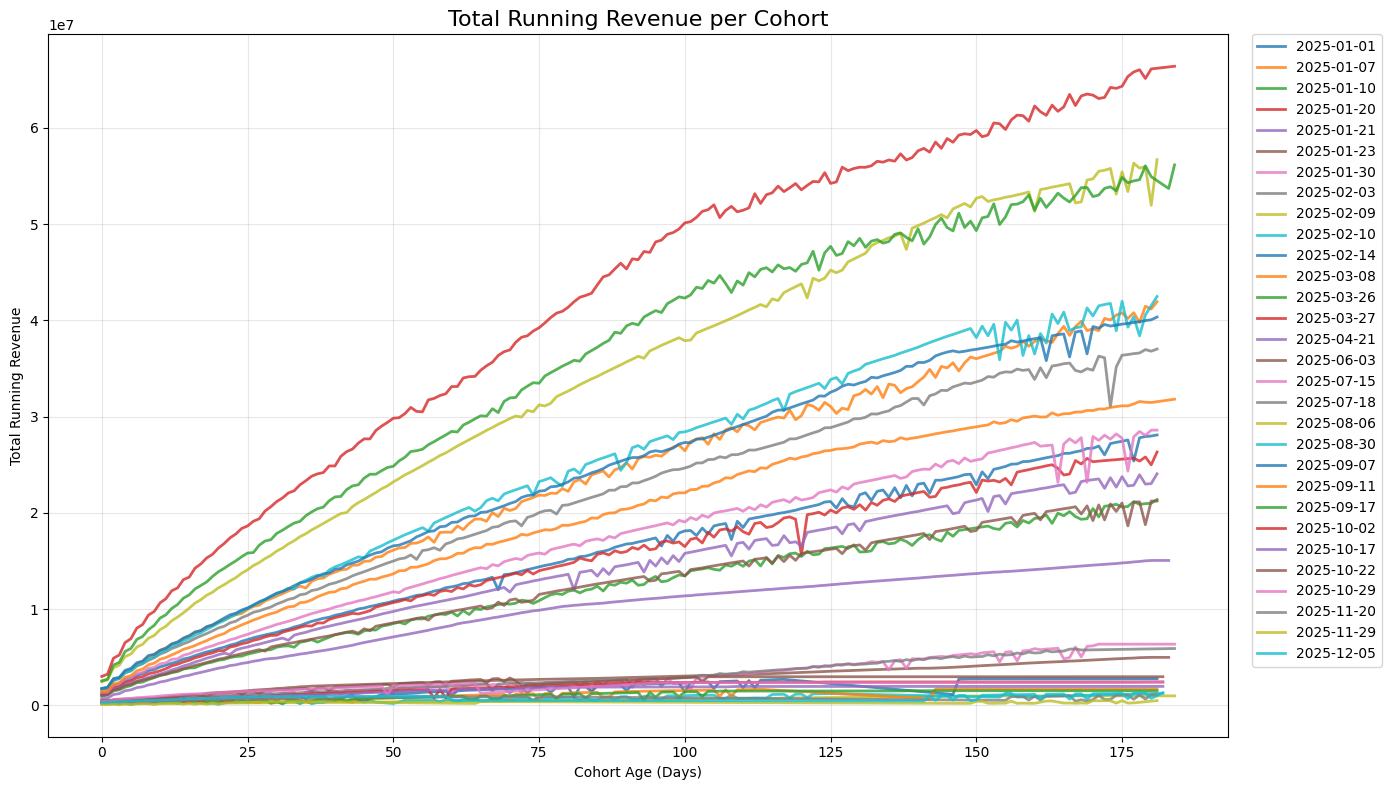

In [495]:
import matplotlib.pyplot as plt

sample = (
    df["date_created_at"]
    .drop_duplicates()
    .sample(min(30, df["date_created_at"].nunique()), random_state=42)
)

plt.figure(figsize=(14, 8))

for cohort in sorted(sample):

    temp = (
        df[df["date_created_at"] == cohort]
        .groupby("cohort_age", as_index=False)["revenue_running_total"]
        .sum()
        .sort_values("cohort_age")
    )

    plt.plot(
        temp["cohort_age"],
        temp["revenue_running_total"],
        linewidth=2,
        alpha=0.8,
        label=cohort.strftime("%Y-%m-%d")
    )

plt.title("Total Running Revenue per Cohort", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Total Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Average revenue daily push distribution per cohort age

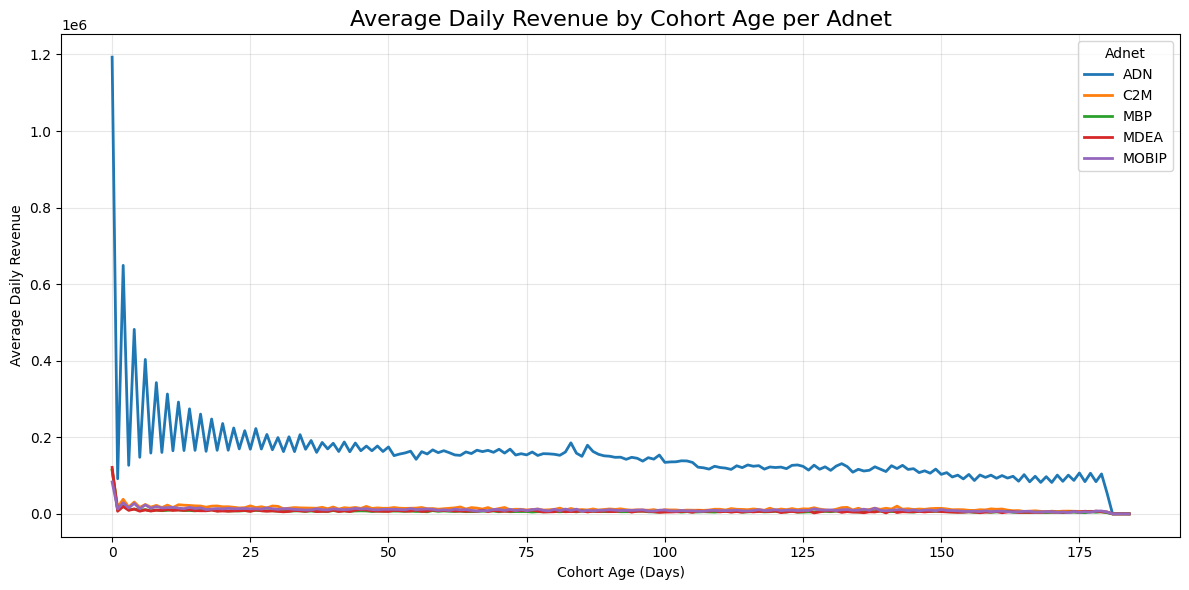

In [496]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for adnet, temp in (
    df.groupby("adnet")
):

    avg_daily = (
        temp
        .groupby("cohort_age")["revenue_dailypush"]
        .mean()
    )

    plt.plot(
        avg_daily.index,
        avg_daily.values,
        linewidth=2,
        label=adnet
    )

plt.title("Average Daily Revenue by Cohort Age per Adnet", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Average Daily Revenue")
plt.grid(alpha=0.3)
plt.legend(title="Adnet")

plt.tight_layout()
plt.show()

Average total revenue distribution per cohort age

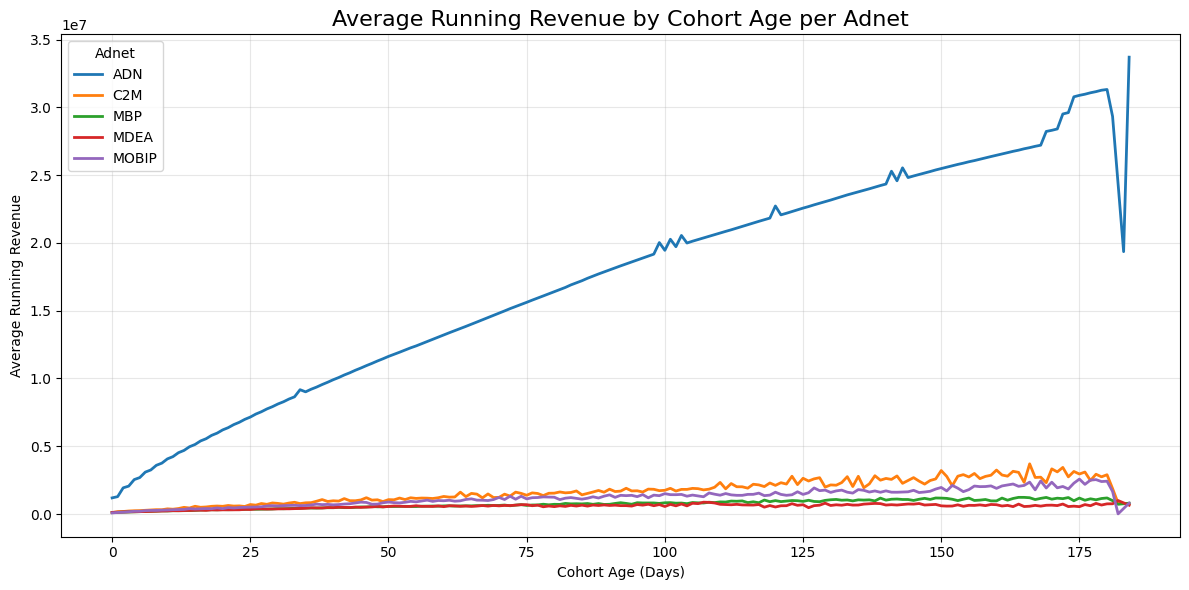

In [497]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for adnet, temp in df.groupby("adnet"):

    avg_running = (
        temp
        .groupby("cohort_age")["revenue_running_total"]
        .mean()
    )

    plt.plot(
        avg_running.index,
        avg_running.values,
        linewidth=2,
        label=adnet
    )

plt.title("Average Running Revenue by Cohort Age per Adnet", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Average Running Revenue")
plt.grid(alpha=0.3)
plt.legend(title="Adnet")

plt.tight_layout()
plt.show()

Numerical correlation

<Axes: >

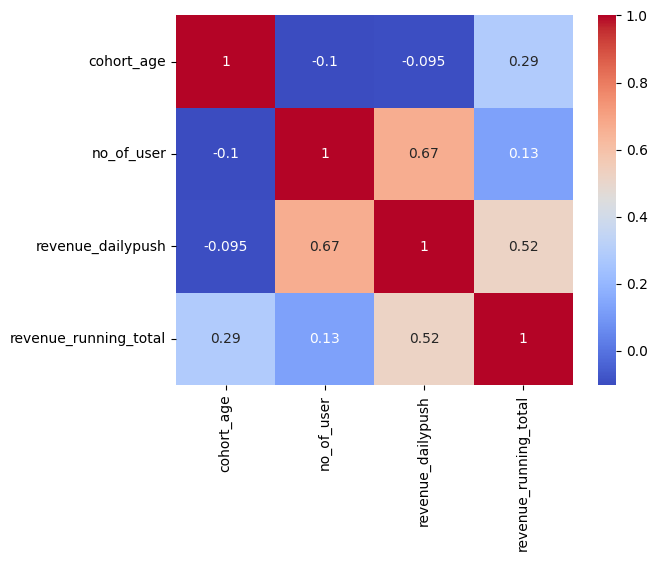

In [498]:
numeric_cols = [
    'cohort_age',
    'no_of_user',
    'revenue_dailypush',
    'revenue_running_total'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

## Preprocessing

### Sort Data

Final preparation with sorting date created and cohort age

In [595]:
df = (
    df
    .sort_values(
        ['date_created_at', 'cohort_age']
    )
    .reset_index(drop=True)
)

In [596]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0,2,0,1
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,0,1
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0,2,0,1
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0,2,0,1
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1,3,0,2


### Encoding

Create new dataframe for preprocessing process

In [597]:
df_model = df.copy()

subject_encoder = LabelEncoder()
adnet_encoder = LabelEncoder()

Subject encoding

In [598]:
df_model['subject_encoded'] = subject_encoder.fit_transform(df_model['subject'])

In [599]:
df_model.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month,subject_encoded
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0,2,0,1,1
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,0,1,1
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0,2,0,1,1
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0,2,0,1,1
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1,3,0,2,0


Adnet encoding

In [600]:
df_model['adnet_encoded'] = adnet_encoder.fit_transform(df_model['adnet'])

In [601]:
df_model.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month,subject_encoded,adnet_encoded
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0,2,0,1,1,1
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0,2,0,1,1,2
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0,2,0,1,1,0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0,2,0,1,1,4
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1,3,0,2,0,4


### Feature Selection

Selecting feature for new dataframe

In [602]:
KEEP_COLS = [
    'date_created_at',      
    'adnet_encoded',        
    'cohort_age',
    'revenue_running_total',
    'day_of_week',
    'weekend',
    'day_of_month',
]

df_model = df_model[KEEP_COLS]

In [603]:
df_model.head()

,date_created_at,adnet_encoded,cohort_age,revenue_running_total,day_of_week,weekend,day_of_month
0,2025-01-01,1,0,6000.0,2,0,1
1,2025-01-01,2,0,136000.0,2,0,1
2,2025-01-01,0,0,1054000.0,2,0,1
3,2025-01-01,4,0,68000.0,2,0,1
4,2025-01-01,4,1,84000.0,3,0,2


### Split Data

Split to train 80% and validation 20% from total cohorts

In [604]:
cohorts = sorted(df_model['date_created_at'].unique())

split_idx = int(len(cohorts) * 0.9)

train_cohorts = cohorts[:split_idx]
val_cohorts = cohorts[split_idx:]

In [605]:
print("Total Train Cohort:", len(train_cohorts))
print("Sample Train Cohort:", train_cohorts)

print("Total Val Cohort:", len(val_cohorts))
print("Sample Val Cohort:", val_cohorts)

Total Train Cohort: 37
Sample Train Cohort: [Timestamp('2025-01-01 00:00:00'), Timestamp('2025-01-07 00:00:00'), Timestamp('2025-01-10 00:00:00'), Timestamp('2025-01-14 00:00:00'), Timestamp('2025-01-20 00:00:00'), Timestamp('2025-01-21 00:00:00'), Timestamp('2025-01-23 00:00:00'), Timestamp('2025-01-28 00:00:00'), Timestamp('2025-01-30 00:00:00'), Timestamp('2025-02-03 00:00:00'), Timestamp('2025-02-08 00:00:00'), Timestamp('2025-02-09 00:00:00'), Timestamp('2025-02-10 00:00:00'), Timestamp('2025-02-14 00:00:00'), Timestamp('2025-02-17 00:00:00'), Timestamp('2025-03-08 00:00:00'), Timestamp('2025-03-26 00:00:00'), Timestamp('2025-03-27 00:00:00'), Timestamp('2025-03-30 00:00:00'), Timestamp('2025-04-21 00:00:00'), Timestamp('2025-05-13 00:00:00'), Timestamp('2025-06-03 00:00:00'), Timestamp('2025-06-24 00:00:00'), Timestamp('2025-07-13 00:00:00'), Timestamp('2025-07-15 00:00:00'), Timestamp('2025-07-18 00:00:00'), Timestamp('2025-08-06 00:00:00'), Timestamp('2025-08-30 00:00:00'), Tim

Insert to pandas for next step (scaling)

In [606]:
train_df = df_model[df_model['date_created_at'].isin(train_cohorts)]
val_df = df_model[df_model['date_created_at'].isin(val_cohorts)]

In [607]:
train_df.head()

,date_created_at,adnet_encoded,cohort_age,revenue_running_total,day_of_week,weekend,day_of_month
0,2025-01-01,1,0,6000.0,2,0,1
1,2025-01-01,2,0,136000.0,2,0,1
2,2025-01-01,0,0,1054000.0,2,0,1
3,2025-01-01,4,0,68000.0,2,0,1
4,2025-01-01,4,1,84000.0,3,0,2


### Scaling

Setup feature and target for training

In [608]:
# Features to be scaled (continuous with large ranges)
FEATURES_SCALING = [
    'revenue_running_total',
    'cohort_age',
]

# All features used for model input (scaled + unscaled)
FEATURES = [
    'revenue_running_total',
    'cohort_age',
    'day_of_week',
    'weekend',
    'day_of_month',
]

TARGET = 'revenue_running_total'

Scaling to make better input in time series model, using min-max scaler

In [609]:
scaler = MinMaxScaler()

# Fit on train only - ONLY scale continuous variables
train_df = train_df.copy()
val_df   = val_df.copy()

train_df[FEATURES_SCALING] = scaler.fit_transform(train_df[FEATURES_SCALING])
val_df[FEATURES_SCALING]   = scaler.transform(val_df[FEATURES_SCALING])

Checking data train

In [610]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15388 entries, 0 to 15387
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        15388 non-null  datetime64[ns]
 1   adnet_encoded          15388 non-null  int64         
 2   cohort_age             15388 non-null  float64       
 3   revenue_running_total  15388 non-null  float64       
 4   day_of_week            15388 non-null  int32         
 5   weekend                15388 non-null  int64         
 6   day_of_month           15388 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(2)
memory usage: 841.5 KB


In [611]:
train_df.head()

,date_created_at,adnet_encoded,cohort_age,revenue_running_total,day_of_week,weekend,day_of_month
0,2025-01-01,1,0.000000,0.000062,2,0,1
1,2025-01-01,2,0.000000,0.001410,2,0,1
2,2025-01-01,0,0.000000,0.010931,2,0,1
3,2025-01-01,4,0.000000,0.000705,2,0,1
4,2025-01-01,4,0.005435,0.000871,3,0,2


Checking data validation

In [612]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 690 entries, 15388 to 16077
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date_created_at        690 non-null    datetime64[ns]
 1   adnet_encoded          690 non-null    int64         
 2   cohort_age             690 non-null    float64       
 3   revenue_running_total  690 non-null    float64       
 4   day_of_week            690 non-null    int32         
 5   weekend                690 non-null    int64         
 6   day_of_month           690 non-null    int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(2)
memory usage: 37.7 KB


In [613]:
val_df.head()

,date_created_at,adnet_encoded,cohort_age,revenue_running_total,day_of_week,weekend,day_of_month
15388,2025-11-02,2,0.000000,0.002323,6,1,2
15389,2025-11-02,3,0.000000,0.001141,6,1,2
15390,2025-11-02,1,0.000000,0.000083,6,1,2
15391,2025-11-02,2,0.005435,0.002406,0,0,3
15392,2025-11-02,3,0.005435,0.001203,0,0,3


## Sequence Generation

### Sliding Window

Setup window size with 30 days and build sequence per cohort **and adnet** (grouped by `date_created_at` + `adnet_encoded`) so windows never mix data across different adnets

In [614]:
WINDOW_SIZE = SEED_DAYS

def create_sequences(data, features, target, window_size, group_cols=('date_created_at', 'adnet_encoded')):

    X = []
    y = []

    group_cols = list(group_cols)

    # Group by cohort AND adnet so sequences never mix data across adnets
    for _, group_df in data.groupby(group_cols):

        group_df = group_df.sort_values('cohort_age')
        feature_values = group_df[features].values
        target_values = group_df[target].values

        for i in range(len(group_df) - window_size):

            X.append(feature_values[i:i+window_size])
            y.append(target_values[i+window_size])

    return np.array(X), np.array(y)

### Generate Sequence

In [615]:
X_train, y_train = create_sequences(
    train_df,
    FEATURES,
    TARGET,
    WINDOW_SIZE
)

X_val, y_val = create_sequences(
    val_df,
    FEATURES,
    TARGET,
    WINDOW_SIZE
)

Checking shape sequence

In [616]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

(12031, 30, 5)
(12031,)
(360, 30, 5)
(360,)


## Modeling

### LSTM

Building model

In [617]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [618]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 30, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,977 (511.63 KB)

 Trainable params: 130,977 (511.63 KB)

 Non-trainable params: 0 (0.00 B)

Compiler

In [619]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mape']
)

Training

In [620]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=200,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0078 - mape: 407.7881 - val_loss: 2.0556e-04 - val_mape: 330.1228
Epoch 2/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 7.8469e-04 - mape: 131.4761 - val_loss: 7.1397e-05 - val_mape: 208.3591
Epoch 3/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5.9972e-04 - mape: 110.0438 - val_loss: 8.2253e-05 - val_mape: 222.8120
Epoch 4/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 5.0717e-04 - mape: 101.8483 - val_loss: 5.5416e-05 - val_mape: 177.8314
Epoch 5/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 3.9219e-04 - mape: 89.0928 - val_loss: 7.4432e-05 - val_mape: 206.4534
Epoch 6/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 3.6999e-04 - mape: 83.0332 - val_loss: 1.5433e-05 - val_mape: 97.4680
Epoch 7/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 3.2540e-04 - mape: 80.1600 - val_loss: 2.0410e-05 - val_mape: 110.4789
Epoch 8/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 3.3868e-

## Evaluation

### Visualization

Loss visualization from training process

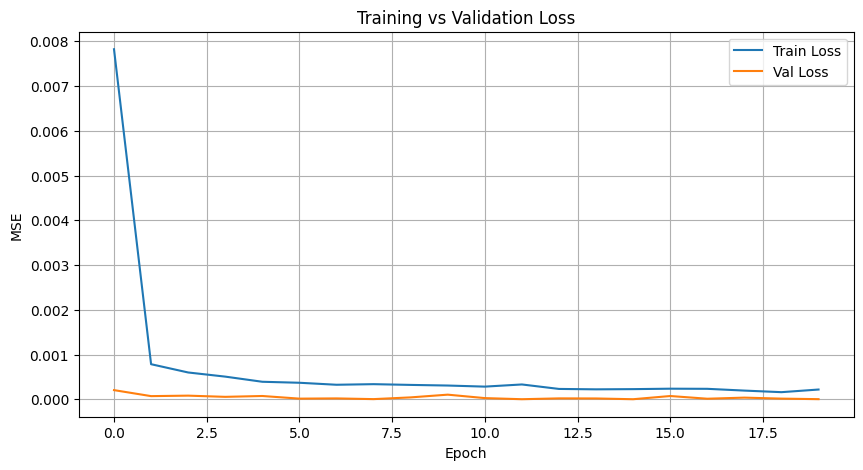

In [621]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.show()

MAPE visualization from training process

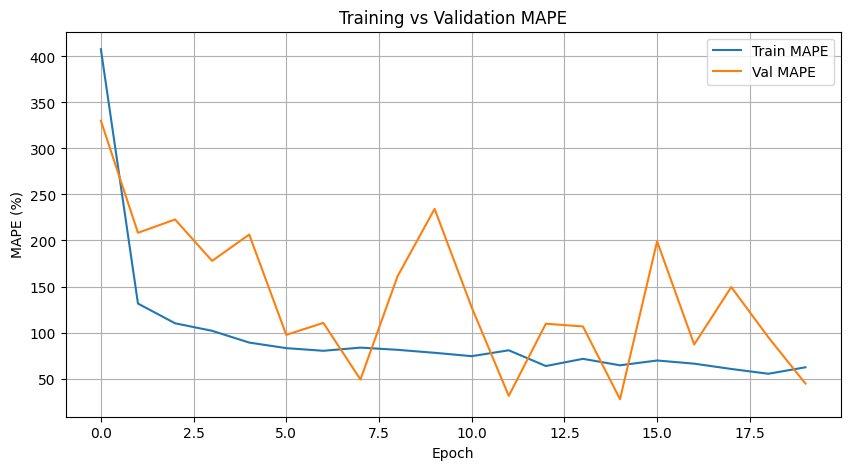

In [622]:
plt.figure(figsize=(10,5))

plt.plot(history.history['mape'], label='Train MAPE')
plt.plot(history.history['val_mape'], label='Val MAPE')

plt.title('Training vs Validation MAPE')
plt.xlabel('Epoch')
plt.ylabel('MAPE (%)')
plt.legend()
plt.grid(True)

plt.show()

In [623]:
y_pred = model.predict(X_val)
y_pred = y_pred.flatten()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


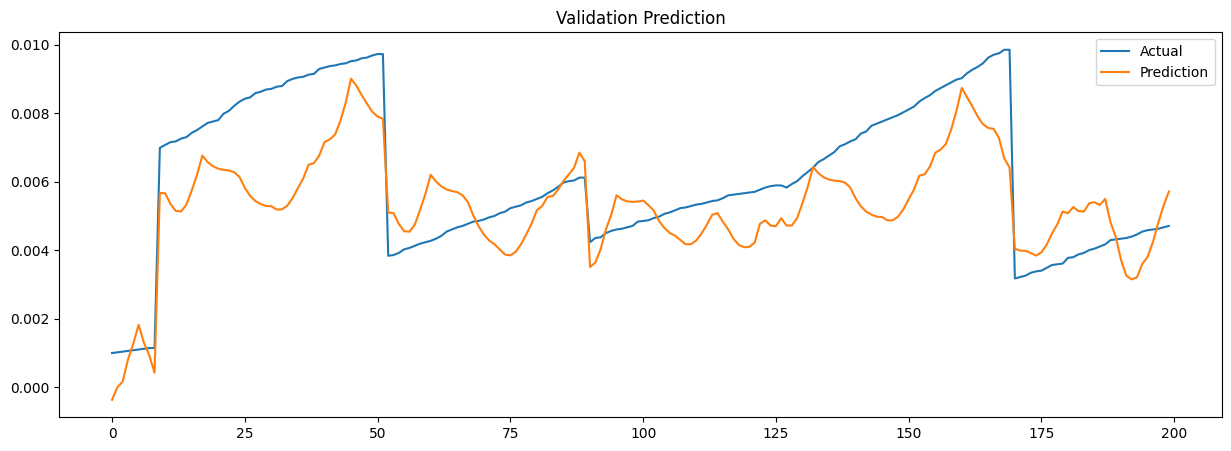

In [624]:
plt.figure(figsize=(15,5))

plt.plot(
    y_val[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Prediction'
)

plt.title('Validation Prediction')

plt.legend()

plt.show()

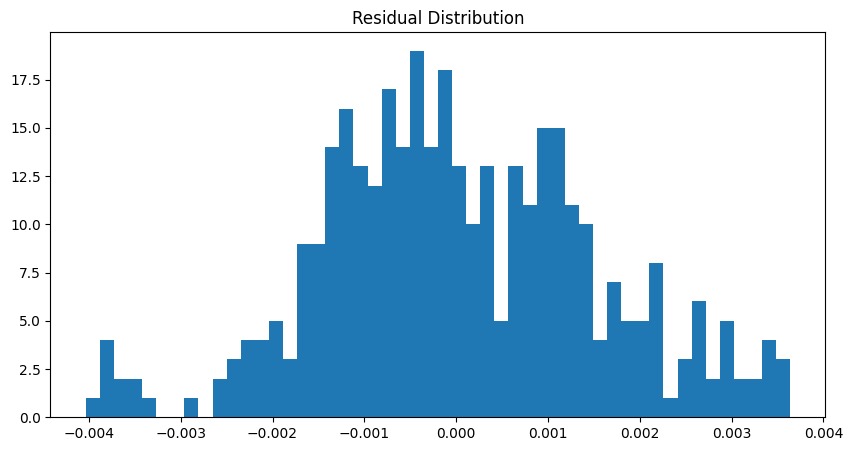

In [625]:
residuals = y_val - y_pred

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=50
)

plt.title('Residual Distribution')

plt.show()

### Metrics

Detail evaluation metrics in MAE, RMSE, MAPE

In [626]:
mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

mape = mean_absolute_percentage_error(
    y_val,
    y_pred
) * 100

In [627]:
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 0.001207
RMSE : 0.001512
MAPE : 27.54%


## Projection

Recursive forecast: first `SEED_DAYS` as input seed, predict all remaining days in the cohort

In [628]:
# REMOVED DOUBLE SCALING - use the original scaler from the Scaling section
# The data is already scaled, no need to scale again!

In [629]:
def inverse_target(scaled_vals):
    """Inverse transform ONLY the scaled features (revenue_running_total, cohort_age)"""
    n = len(scaled_vals)
    
    # Create dummy array with only the SCALED features (2 columns)
    dummy = np.zeros((n, len(FEATURES_SCALING)))
    
    # TARGET is 'revenue_running_total', which is the first column in FEATURES_SCALING
    target_idx_in_scaling = FEATURES_SCALING.index(TARGET)
    dummy[:, target_idx_in_scaling] = scaled_vals
    
    # Inverse transform using scaler (fitted on FEATURES_SCALING)
    return scaler.inverse_transform(dummy)[:, target_idx_in_scaling]


Select cohort and run projection

In [630]:
candidates = [c for c in val_cohorts
              if int(df[df["date_created_at"] == c]["cohort_age"].max()) >= SEED_DAYS]
print("Eligible cohorts:", len(candidates))

cohort = candidates[1]
available_adnets = df.loc[df["date_created_at"] == cohort, "adnet"].unique()
print("Available Adnets:", available_adnets)

adnet      = available_adnets[0]
adnet_code = adnet_encoder.transform([adnet])[0]

# Unscaled — untuk slicing dan x-axis
cohort_raw = (
    df[(df["date_created_at"] == cohort) & (df["adnet"] == adnet)]
    .sort_values("cohort_age")
    .reset_index(drop=True)
)

# Scaled — untuk input model
cohort_df = (
    val_df[(val_df["date_created_at"] == cohort) & (val_df["adnet_encoded"] == adnet_code)]
    .sort_values("cohort_age")
    .reset_index(drop=True)
)

seed_mask = cohort_raw["cohort_age"] < SEED_DAYS
seed_df   = cohort_df[seed_mask.values].reset_index(drop=True)
future_df = cohort_df[~seed_mask.values].reset_index(drop=True)
n_steps   = len(future_df)

seed = seed_df[FEATURES].values[-WINDOW_SIZE:]

future_features_scaled = future_df[FEATURES].values.copy()
future_features_scaled[:, FEATURES.index(TARGET)] = 0

print("Cohort      :", cohort)
print("Adnet       :", adnet)
print("Seed days   :", len(seed_df))
print("Future days :", n_steps)

# Forecast
pred_scaled = forecast_recursive(model, seed, future_features_scaled)

pred_running = inverse_target(pred_scaled)

# Get actual_running from RAW (unscaled) data, NOT from scaled cohort_df!
actual_running = cohort_raw.loc[~seed_mask, TARGET].values.astype(float)

print(f"Predicted running total at day {SEED_DAYS + n_steps - 1}: {pred_running[-1]:,.0f}")
print(f"Actual    running total at day {SEED_DAYS + n_steps - 1}: {actual_running[-1]:,.0f}")


Eligible cohorts: 5
Available Adnets: ['MBP' 'MDEA']
Cohort      : 2025-11-05 00:00:00
Adnet       : MBP
Seed days   : 29
Future days : 38
Predicted running total at day 67: 524,064
Actual    running total at day 67: 568,000


Evaluation at day+30, day+60, and full horizon

In [631]:
milestones = {'day+30': 30, 'day+60': 60, 'full': n_steps}

for label, days in milestones.items():
    n = min(days, len(actual_running), len(pred_running))
    if n == 0:
        print(f"{label}: not enough data")
        continue
    mae  = mean_absolute_error(actual_running[:n], pred_running[:n])
    rmse = np.sqrt(mean_squared_error(actual_running[:n], pred_running[:n]))
    mape = mean_absolute_percentage_error(actual_running[:n], pred_running[:n]) * 100
    print(f"[{label:>7}] MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  MAPE={mape:.2f}%")

[ day+30] MAE=      58,715  RMSE=      70,297  MAPE=12.45%
[ day+60] MAE=      57,534  RMSE=      67,391  MAPE=11.83%
[   full] MAE=      57,534  RMSE=      67,391  MAPE=11.83%


Actual vs projection visualization

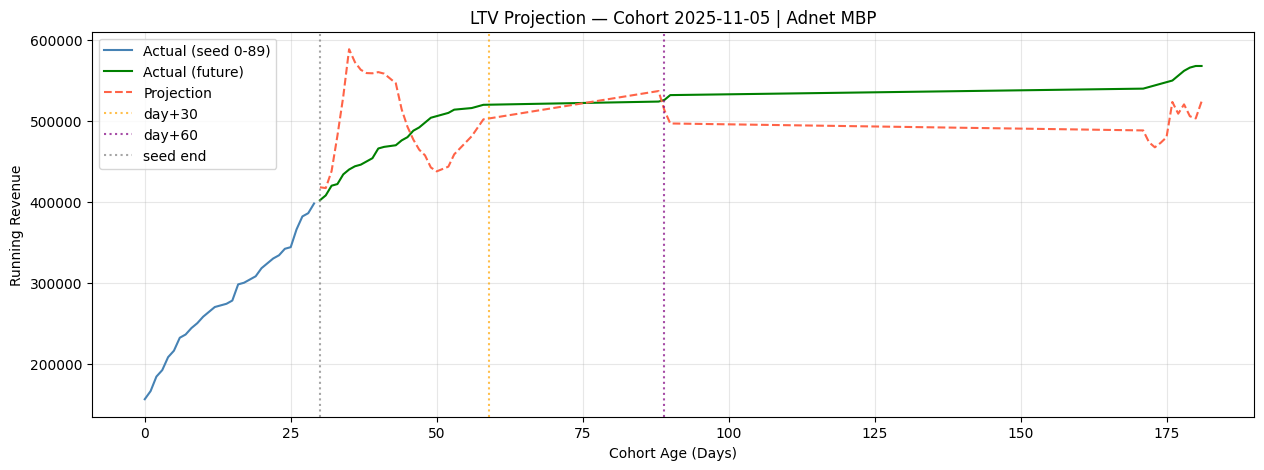

In [632]:
# Get seed_running from RAW (unscaled) data
seed_running = cohort_raw.loc[seed_mask, TARGET].values.astype(float)

# cohort_age is scaled in val_df — use original df for x-axis values
seed_age   = cohort_raw[cohort_raw['cohort_age'] < SEED_DAYS]['cohort_age'].values
future_age = cohort_raw[cohort_raw['cohort_age'] >= SEED_DAYS]['cohort_age'].values[:n_steps]
pred_age   = future_age[:len(pred_running)]

plt.figure(figsize=(15, 5))

plt.plot(seed_age,   seed_running,   label='Actual (seed 0-89)',  color='steelblue')
plt.plot(future_age, actual_running, label='Actual (future)',      color='green')
plt.plot(pred_age,   pred_running,   label='Projection',           color='tomato', linestyle='--')

for offset, color in [(30, 'orange'), (60, 'purple')]:
    day = SEED_DAYS + offset - 1
    if len(future_age) > 0 and day <= future_age[-1]:
        plt.axvline(x=day, color=color, linestyle=':', alpha=0.7, label=f'day+{offset}')

plt.axvline(x=SEED_DAYS, color='gray', linestyle=':', alpha=0.7, label='seed end')
plt.title(f'LTV Projection — Cohort {str(cohort)[:10]} | Adnet {adnet}')
plt.xlabel('Cohort Age (Days)')
plt.ylabel('Running Revenue')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Testing on Unseen Data

This section evaluates the trained LSTM model on a completely hold-out dataset (`linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts`) containing 5 unseen cohorts that were never seen during training or validation.

Unlike TimeFM, the LSTM is a **supervised, multivariate** model trained on scaled features. The unseen data must therefore go through the **same preprocessing pipeline** as the training data:

- Feature engineering: `cohort_age`, `day_of_week`, `weekend`, `day_of_month`, subject/adnet encoding
- Scaling using `scaler.transform()` (the scaler fitted on training data — **no re-fitting** to avoid data leakage)
- Sliding window construction and recursive forecasting

The `inverse_target()` helper and `forecast_recursive()` function defined in the Projection section are reused here.

### Loader

Query the unseen testing table from Google BigQuery

In [633]:
# df_unseen = pd.read_gbq(unseen_query, project_id=project_id, dialect='standard')
# df_unseen.head()

df_unseen = unseen_raw.copy()

### Feature Engineering

Apply the same feature engineering as the training data: parse dates, compute `cohort_age`, add `day_of_week`, `weekend`, `day_of_month`, and sort. This is required because the LSTM was trained on these features.

In [634]:
df_unseen['date_created_at'] = pd.to_datetime(df_unseen['date_created_at'])
df_unseen['date_update']     = pd.to_datetime(df_unseen['date_update'])

df_unseen['cohort_age'] = (
    df_unseen['date_update'] - df_unseen['date_created_at']
).dt.days

df_unseen['day_of_week'] = df_unseen['date_update'].dt.dayofweek
df_unseen['weekend'] = (df_unseen['date_update'].dt.dayofweek >= 5).astype(int)
df_unseen['day_of_month'] = df_unseen['date_update'].dt.day

df_unseen = (
    df_unseen
    .sort_values(['date_created_at', 'cohort_age'])
    .reset_index(drop=True)
)

df_unseen.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age,day_of_week,weekend,day_of_month
0,2025-11-05,MBP,2025-11-05,975,156000.0,FIRSTPUSH,156000.0,0,2,0,5
1,2025-11-05,MDEA,2025-11-05,955,142000.0,FIRSTPUSH,142000.0,0,2,0,5
2,2025-11-05,MDEA,2025-11-06,6,12000.0,DAILYPUSH,154000.0,1,3,0,6
3,2025-11-05,MBP,2025-11-06,5,10000.0,DAILYPUSH,166000.0,1,3,0,6
4,2025-11-05,MDEA,2025-11-07,15,30000.0,DAILYPUSH,184000.0,2,4,0,7


Subject and adnet encoding using the encoders fitted on training data

In [635]:
df_unseen['subject_encoded'] = subject_encoder.transform(df_unseen['subject'])
df_unseen['adnet_encoded']   = adnet_encoder.transform(df_unseen['adnet'])

Feature selection — keep the same columns as the training data

In [636]:
df_unseen_model = df_unseen[KEEP_COLS].copy()

Checking unseen cohorts and their length

In [637]:
unseen_cohorts = sorted(df_unseen["date_created_at"].unique())

print("Total unseen cohorts:", len(unseen_cohorts))

for cohort in unseen_cohorts:

    print(f"\nCohort: {str(cohort)[:10]}")

    temp = (
        df_unseen[
            df_unseen["date_created_at"] == cohort
        ]
        .groupby("adnet")["cohort_age"]
        .max()
        .sort_index()
    )

    for adnet, max_age in temp.items():
        print(f"  {adnet:<6} -> {int(max_age)+1} days")

Total unseen cohorts: 4

Cohort: 2025-11-05
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-11-20
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-11-29
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-12-05
  MBP    -> 183 days
  MDEA   -> 183 days


### Scaling

Apply `scaler.transform()` using the scaler already fitted on the training data. **Do not call `fit_transform()`** here — that would leak unseen data statistics into the scaler and invalidate the test.

In [638]:
df_unseen_model = df_unseen_model.copy()
df_unseen_model[FEATURES_SCALING] = scaler.transform(df_unseen_model[FEATURES_SCALING])

df_unseen_model.head()

,date_created_at,adnet_encoded,cohort_age,revenue_running_total,day_of_week,weekend,day_of_month
0,2025-11-05,2,0.000000,0.001618,2,0,5
1,2025-11-05,3,0.000000,0.001473,2,0,5
2,2025-11-05,3,0.005435,0.001597,3,0,6
3,2025-11-05,2,0.005435,0.001722,3,0,6
4,2025-11-05,3,0.010870,0.001908,4,0,7


### Forecast - 7 Days

In [ ]:
results_unseen = {}

# Iterate over (cohort, adnet) pairs so each adnet series is forecast separately
for (cohort, adnet), cohort_raw in (
    df_unseen.groupby(['date_created_at', 'adnet'])
):

    # Unscaled — for age-based slicing and x-axis
    cohort_raw = (
        cohort_raw
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    adnet_code = adnet_encoder.transform([adnet])[0]

    # Scaled — model input (same cohort AND adnet)
    cohort_scaled = (
        df_unseen_model[
            (df_unseen_model['date_created_at'] == cohort)
            & (df_unseen_model['adnet_encoded'] == adnet_code)
        ]
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    if len(cohort_raw) <= WINDOW_SIZE:
        # Not enough history to build a seed window — skip
        continue

    seed_len  = min(SEED_DAYS, len(cohort_raw) - 1)
    seed_idx  = cohort_raw[cohort_raw['cohort_age'] < seed_len].index

    seed_df_u   = cohort_scaled.iloc[:len(seed_idx)]
    future_df_u = cohort_scaled.iloc[len(seed_idx):].reset_index(drop=True)
    n_steps     = len(future_df_u)

    if n_steps == 0:
        continue

    seed = seed_df_u[FEATURES].values[-WINDOW_SIZE:]

    future_features_scaled_u = future_df_u[FEATURES].values.copy()
    future_features_scaled_u[:, FEATURES.index(TARGET)] = 0

    pred_scaled_u = forecast_recursive(model, seed, future_features_scaled_u)

    pred_running_u = inverse_target(pred_scaled_u)
    
    # Get actual_running from RAW (unscaled) data, NOT from scaled cohort_scaled!
    seed_mask_u = cohort_raw['cohort_age'] < seed_len
    actual_running_u = cohort_raw.loc[~seed_mask_u, TARGET].values.astype(float)

    results_unseen[(cohort, adnet)] = {
        'cohort_raw': cohort_raw,
        'adnet': adnet,
        'seed_len': seed_len,
        'seed_df': seed_df_u,
        'pred_running': pred_running_u,
        'actual_running': actual_running_u,
        'n_steps': n_steps,
    }

    # Calculate MAPE for full horizon
    mape_full = mean_absolute_percentage_error(actual_running_u, pred_running_u) * 100
    print(f"{str(cohort)[:10]} | {adnet}: seed={seed_len}d, forecast={n_steps}d  | final pred={pred_running_u[-1]:,.0f}  actual={actual_running_u[-1]:,.0f}  MAPE={mape_full:.2f}%")

2025-11-05 | MBP: seed=7d, forecast=60d  | final pred=863,136  actual=568,000  MAPE=20.75%
2025-11-05 | MDEA: seed=7d, forecast=66d  | final pred=863,579  actual=950,000  MAPE=24.14%
2025-11-20 | MBP: seed=7d, forecast=55d  | final pred=699,811  actual=456,000  MAPE=50.45%
2025-11-20 | MDEA: seed=7d, forecast=64d  | final pred=786,089  actual=640,000  MAPE=22.81%
2025-11-29 | MBP: seed=7d, forecast=43d  | final pred=7,878,255  actual=232,000  MAPE=1980.22%
2025-11-29 | MDEA: seed=7d, forecast=50d  | final pred=1,075,699  actual=254,000  MAPE=410.89%
2025-12-05 | MBP: seed=7d, forecast=56d  | final pred=909,691  actual=584,000  MAPE=25.79%
2025-12-05 | MDEA: seed=7d, forecast=63d  | final pred=846,663  actual=718,000  MAPE=16.92%


Actual vs projection visualization for unseen cohorts

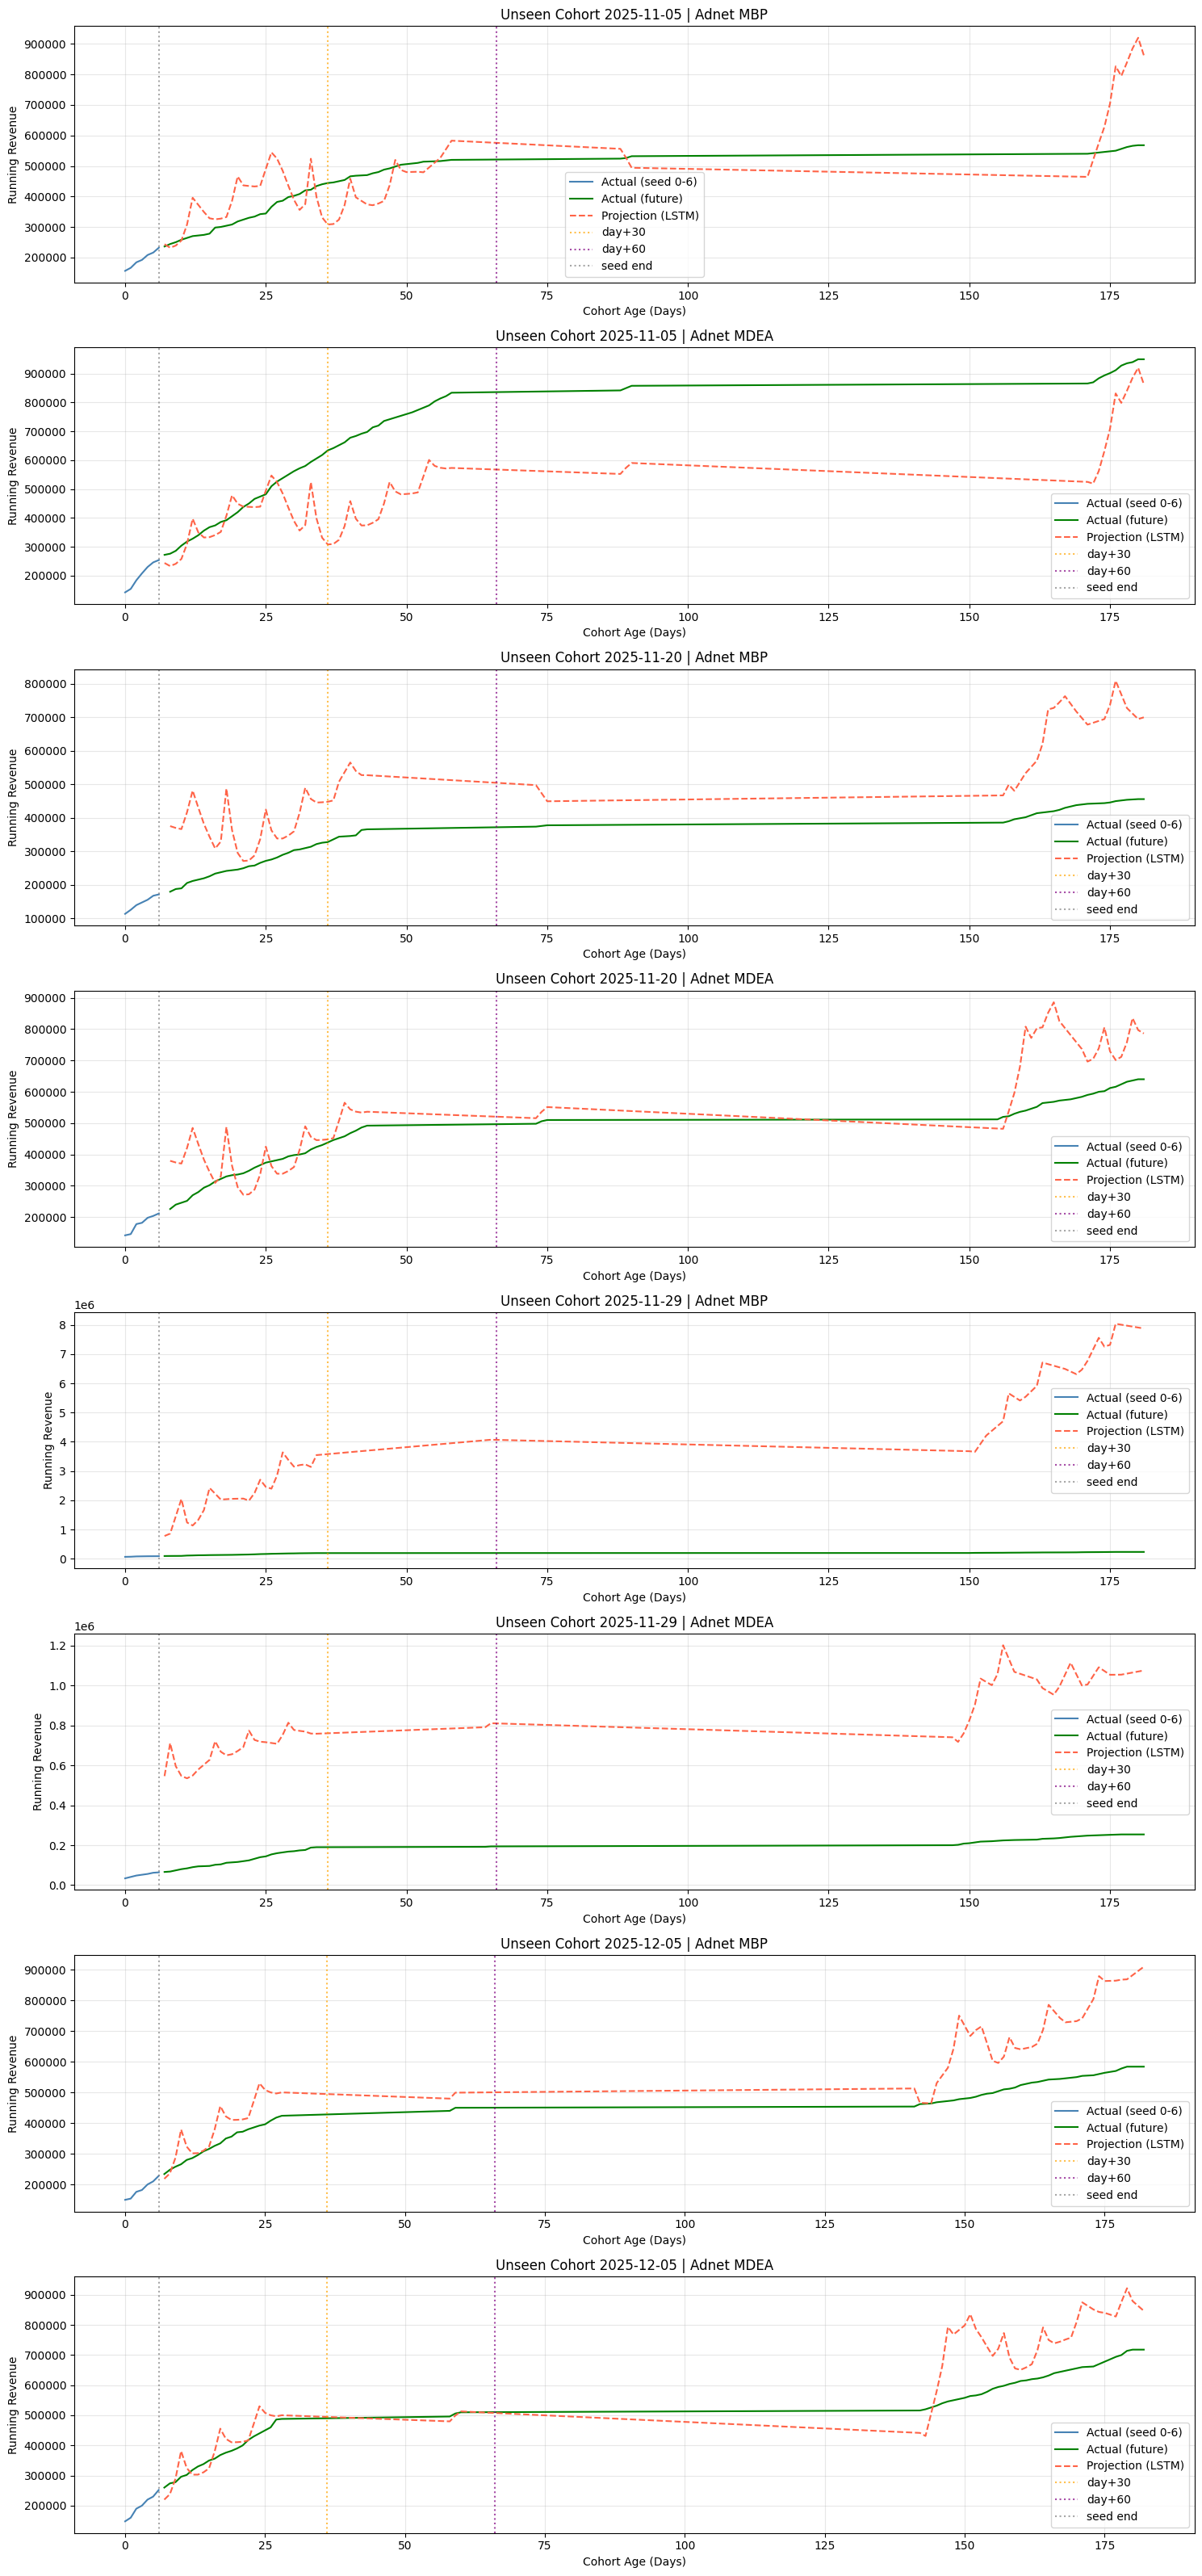

In [ ]:
n_cohorts = len(results_unseen)
fig, axes = plt.subplots(n_cohorts, 1, figsize=(15, 4 * n_cohorts))

if n_cohorts == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results_unseen.items()):
    cohort_raw = r['cohort_raw']
    seed_len   = r['seed_len']
    n_steps    = r['n_steps']

    # Get seed_running from RAW (unscaled) data
    seed_mask_viz = cohort_raw['cohort_age'] < seed_len
    seed_running_u = cohort_raw.loc[seed_mask_viz, TARGET].values.astype(float)

    seed_age   = cohort_raw[cohort_raw['cohort_age'] < seed_len]['cohort_age'].values
    future_age = cohort_raw[cohort_raw['cohort_age'] >= seed_len]['cohort_age'].values[:n_steps]
    pred_age   = future_age[:len(r['pred_running'])]

    ax.plot(seed_age,   seed_running_u,    label=f'Actual (seed 0-{seed_len-1})', color='steelblue')
    ax.plot(future_age, r['actual_running'],label='Actual (future)',              color='green')
    ax.plot(pred_age,   r['pred_running'],  label='Projection (LSTM)',            color='tomato', linestyle='--')

    for offset, color in [(30, 'orange'), (60, 'purple')]:
        day = seed_len + offset - 1
        if len(future_age) > 0 and day <= future_age[-1]:
            ax.axvline(x=day, color=color, linestyle=':', alpha=0.7, label=f'day+{offset}')

    if len(seed_age) > 0:
        ax.axvline(x=seed_age[-1], color='gray', linestyle=':', alpha=0.7, label='seed end')

    ax.set_title(f'Unseen Cohort {str(cohort)[:10]} | Adnet {adnet}')
    ax.set_xlabel('Cohort Age (Days)')
    ax.set_ylabel('Running Revenue')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Forecast - 30 Days

In [ ]:
results_unseen = {}

# Iterate over (cohort, adnet) pairs so each adnet series is forecast separately
for (cohort, adnet), cohort_raw in (
    df_unseen.groupby(['date_created_at', 'adnet'])
):

    # Unscaled — for age-based slicing and x-axis
    cohort_raw = (
        cohort_raw
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    adnet_code = adnet_encoder.transform([adnet])[0]

    # Scaled — model input (same cohort AND adnet)
    cohort_scaled = (
        df_unseen_model[
            (df_unseen_model['date_created_at'] == cohort)
            & (df_unseen_model['adnet_encoded'] == adnet_code)
        ]
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    if len(cohort_raw) <= WINDOW_SIZE:
        # Not enough history to build a seed window — skip
        continue

    seed_len  = min(SEED_DAYS, len(cohort_raw) - 1)
    seed_idx  = cohort_raw[cohort_raw['cohort_age'] < seed_len].index

    seed_df_u   = cohort_scaled.iloc[:len(seed_idx)]
    future_df_u = cohort_scaled.iloc[len(seed_idx):].reset_index(drop=True)
    n_steps     = len(future_df_u)

    if n_steps == 0:
        continue

    seed = seed_df_u[FEATURES].values[-WINDOW_SIZE:]

    future_features_scaled_u = future_df_u[FEATURES].values.copy()
    future_features_scaled_u[:, FEATURES.index(TARGET)] = 0

    pred_scaled_u = forecast_recursive(model, seed, future_features_scaled_u)

    pred_running_u = inverse_target(pred_scaled_u)
    
    # Get actual_running from RAW (unscaled) data, NOT from scaled cohort_scaled!
    seed_mask_u = cohort_raw['cohort_age'] < seed_len
    actual_running_u = cohort_raw.loc[~seed_mask_u, TARGET].values.astype(float)

    results_unseen[(cohort, adnet)] = {
        'cohort_raw': cohort_raw,
        'adnet': adnet,
        'seed_len': seed_len,
        'seed_df': seed_df_u,
        'pred_running': pred_running_u,
        'actual_running': actual_running_u,
        'n_steps': n_steps,
    }

    # Calculate MAPE for full horizon
    mape_full = mean_absolute_percentage_error(actual_running_u, pred_running_u) * 100
    print(f"{str(cohort)[:10]} | {adnet}: seed={seed_len}d, forecast={n_steps}d  | final pred={pred_running_u[-1]:,.0f}  actual={actual_running_u[-1]:,.0f}  MAPE={mape_full:.2f}%")

2025-11-05 | MBP: seed=30d, forecast=38d  | final pred=509,369  actual=568,000  MAPE=54.83%
2025-11-05 | MDEA: seed=30d, forecast=43d  | final pred=699,439  actual=950,000  MAPE=6.36%
2025-11-20 | MBP: seed=30d, forecast=33d  | final pred=811,277  actual=456,000  MAPE=103.86%
2025-11-20 | MDEA: seed=30d, forecast=42d  | final pred=882,717  actual=640,000  MAPE=66.55%
2025-11-29 | MBP: seed=30d, forecast=24d  | final pred=1,782,417  actual=232,000  MAPE=675.93%
2025-11-29 | MDEA: seed=30d, forecast=28d  | final pred=494,158  actual=254,000  MAPE=314.84%
2025-12-05 | MBP: seed=30d, forecast=34d  | final pred=700,587  actual=584,000  MAPE=44.24%
2025-12-05 | MDEA: seed=30d, forecast=41d  | final pred=1,023,393  actual=718,000  MAPE=40.51%


Actual vs projection visualization for unseen cohorts

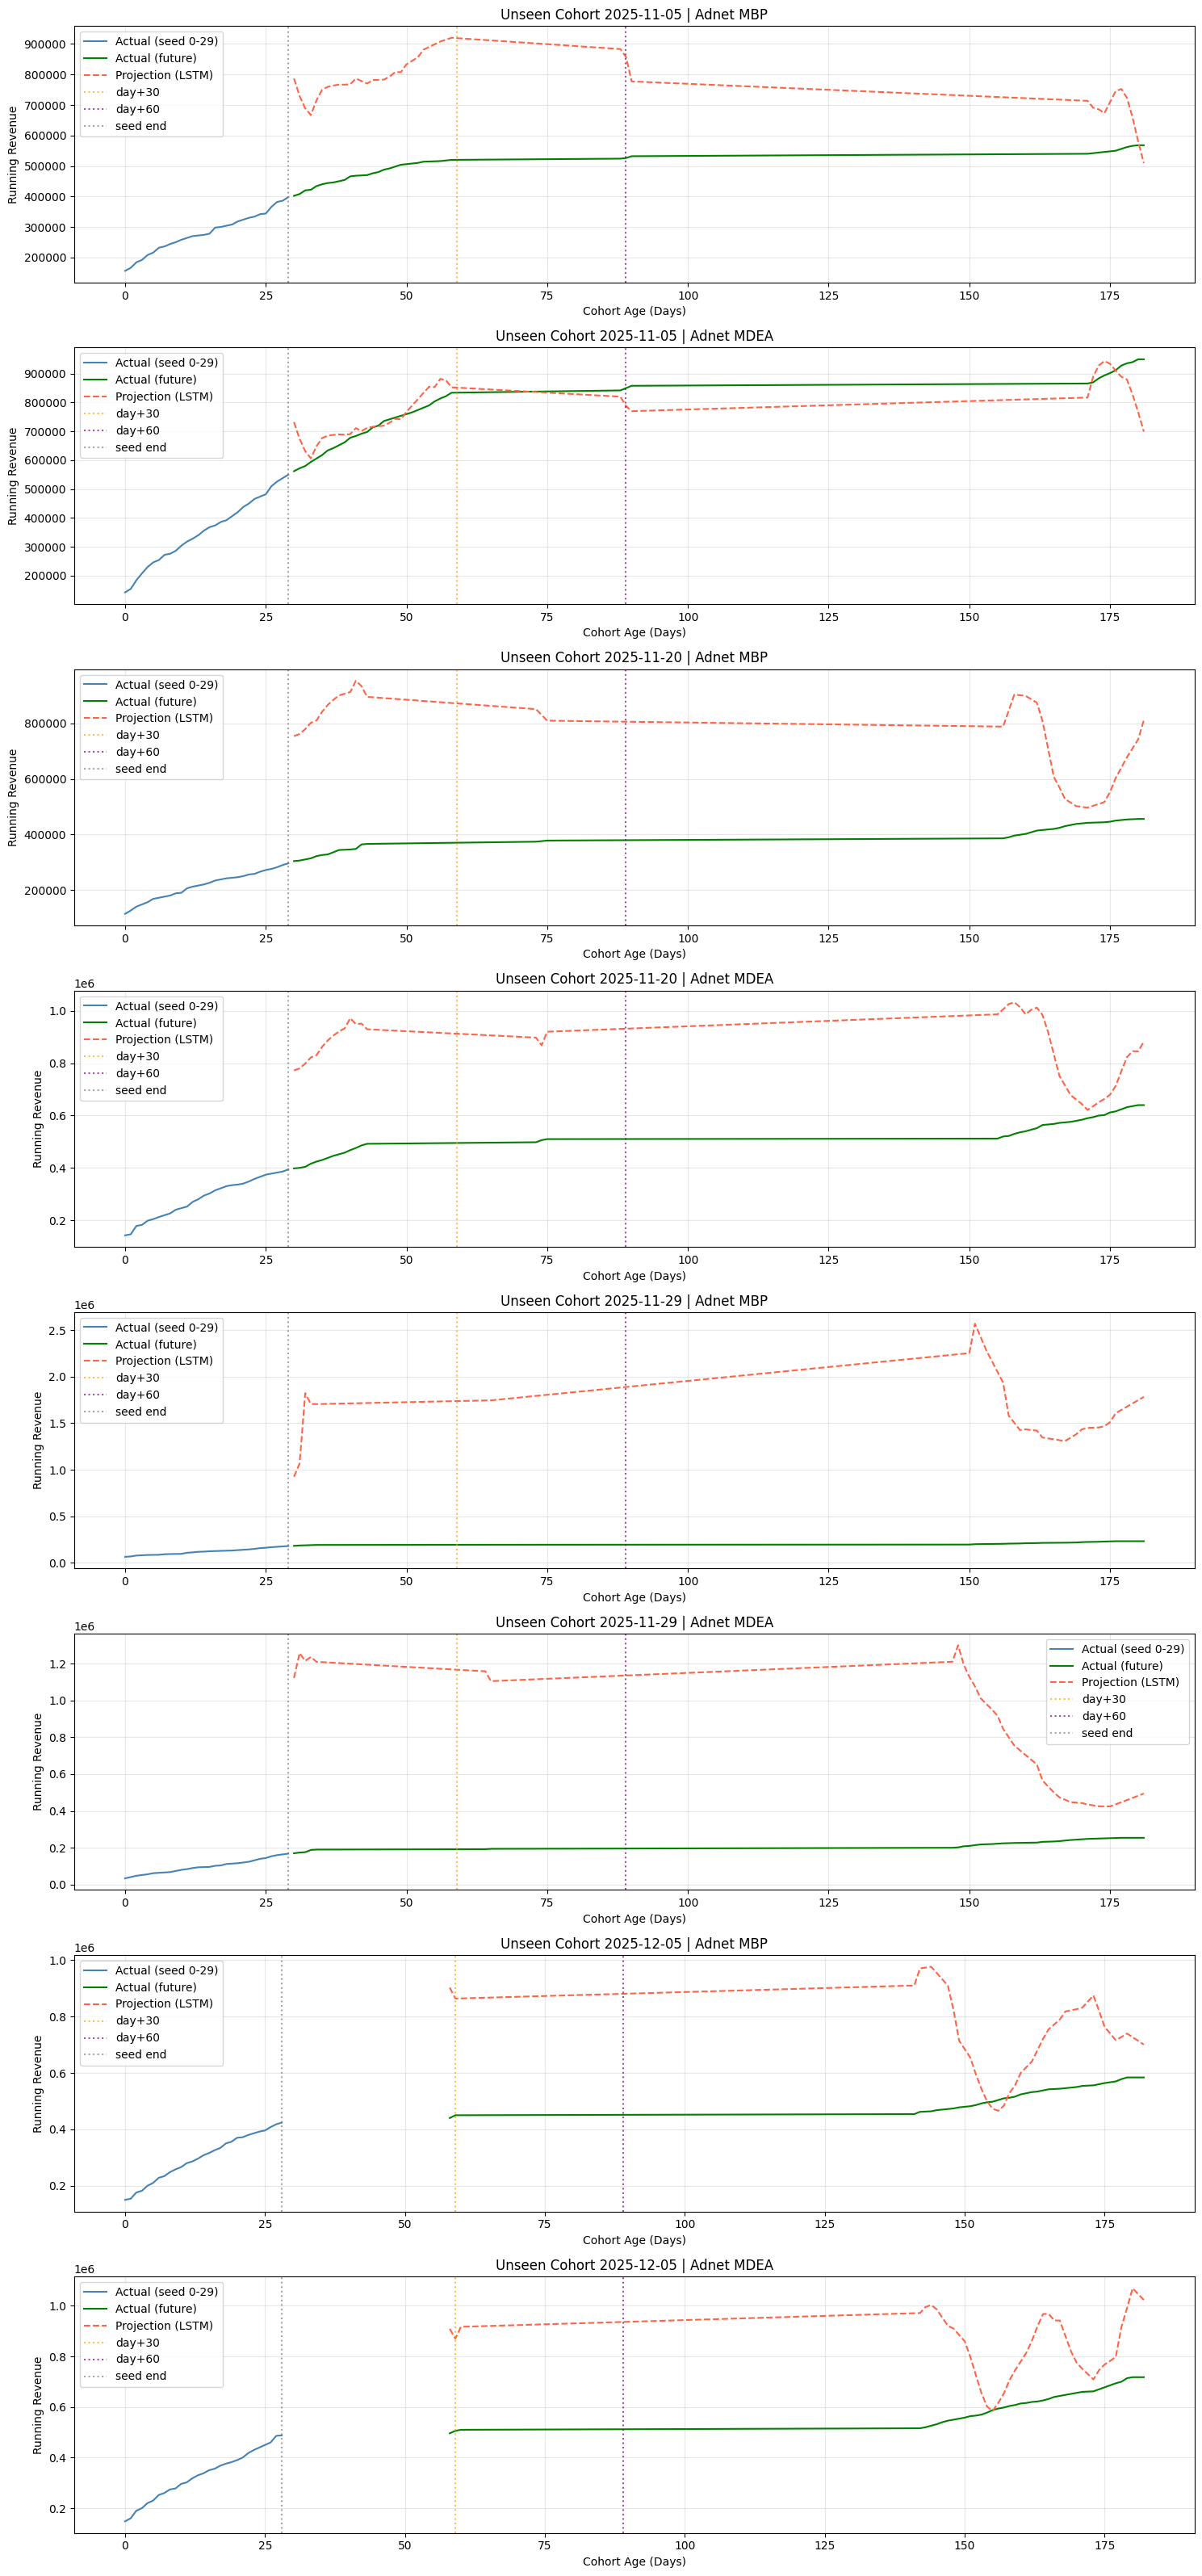

In [ ]:
n_cohorts = len(results_unseen)
fig, axes = plt.subplots(n_cohorts, 1, figsize=(15, 4 * n_cohorts))

if n_cohorts == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results_unseen.items()):
    cohort_raw = r['cohort_raw']
    seed_len   = r['seed_len']
    n_steps    = r['n_steps']

    # Get seed_running from RAW (unscaled) data
    seed_mask_viz = cohort_raw['cohort_age'] < seed_len
    seed_running_u = cohort_raw.loc[seed_mask_viz, TARGET].values.astype(float)

    seed_age   = cohort_raw[cohort_raw['cohort_age'] < seed_len]['cohort_age'].values
    future_age = cohort_raw[cohort_raw['cohort_age'] >= seed_len]['cohort_age'].values[:n_steps]
    pred_age   = future_age[:len(r['pred_running'])]

    ax.plot(seed_age,   seed_running_u,    label=f'Actual (seed 0-{seed_len-1})', color='steelblue')
    ax.plot(future_age, r['actual_running'],label='Actual (future)',              color='green')
    ax.plot(pred_age,   r['pred_running'],  label='Projection (LSTM)',            color='tomato', linestyle='--')

    for offset, color in [(30, 'orange'), (60, 'purple')]:
        day = seed_len + offset - 1
        if len(future_age) > 0 and day <= future_age[-1]:
            ax.axvline(x=day, color=color, linestyle=':', alpha=0.7, label=f'day+{offset}')

    if len(seed_age) > 0:
        ax.axvline(x=seed_age[-1], color='gray', linestyle=':', alpha=0.7, label='seed end')

    ax.set_title(f'Unseen Cohort {str(cohort)[:10]} | Adnet {adnet}')
    ax.set_xlabel('Cohort Age (Days)')
    ax.set_ylabel('Running Revenue')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Forecast - 60 Days

In [711]:
results_unseen = {}

# Iterate over (cohort, adnet) pairs so each adnet series is forecast separately
for (cohort, adnet), cohort_raw in (
    df_unseen.groupby(['date_created_at', 'adnet'])
):

    # Unscaled — for age-based slicing and x-axis
    cohort_raw = (
        cohort_raw
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    adnet_code = adnet_encoder.transform([adnet])[0]

    # Scaled — model input (same cohort AND adnet)
    cohort_scaled = (
        df_unseen_model[
            (df_unseen_model['date_created_at'] == cohort)
            & (df_unseen_model['adnet_encoded'] == adnet_code)
        ]
        .sort_values('cohort_age')
        .reset_index(drop=True)
    )

    if len(cohort_raw) <= WINDOW_SIZE:
        # Not enough history to build a seed window — skip
        continue

    seed_len  = min(SEED_DAYS, len(cohort_raw) - 1)
    seed_idx  = cohort_raw[cohort_raw['cohort_age'] < seed_len].index

    seed_df_u   = cohort_scaled.iloc[:len(seed_idx)]
    future_df_u = cohort_scaled.iloc[len(seed_idx):].reset_index(drop=True)
    n_steps     = len(future_df_u)

    if n_steps == 0:
        continue

    seed = seed_df_u[FEATURES].values[-WINDOW_SIZE:]

    future_features_scaled_u = future_df_u[FEATURES].values.copy()
    future_features_scaled_u[:, FEATURES.index(TARGET)] = 0

    pred_scaled_u = forecast_recursive(model, seed, future_features_scaled_u)

    pred_running_u = inverse_target(pred_scaled_u)
    
    # Get actual_running from RAW (unscaled) data, NOT from scaled cohort_scaled!
    seed_mask_u = cohort_raw['cohort_age'] < seed_len
    actual_running_u = cohort_raw.loc[~seed_mask_u, TARGET].values.astype(float)

    results_unseen[(cohort, adnet)] = {
        'cohort_raw': cohort_raw,
        'adnet': adnet,
        'seed_len': seed_len,
        'seed_df': seed_df_u,
        'pred_running': pred_running_u,
        'actual_running': actual_running_u,
        'n_steps': n_steps,
    }

    # Calculate MAPE for full horizon
    mape_full = mean_absolute_percentage_error(actual_running_u, pred_running_u) * 100
    print(f"{str(cohort)[:10]} | {adnet}: seed={seed_len}d, forecast={n_steps}d  | final pred={pred_running_u[-1]:,.0f}  actual={actual_running_u[-1]:,.0f}  MAPE={mape_full:.2f}%")

2025-11-05 | MBP: seed=60d, forecast=14d  | final pred=738,004  actual=568,000  MAPE=42.85%
2025-11-05 | MDEA: seed=60d, forecast=14d  | final pred=801,779  actual=950,000  MAPE=7.76%
2025-11-20 | MBP: seed=60d, forecast=20d  | final pred=742,499  actual=456,000  MAPE=96.66%
2025-11-20 | MDEA: seed=60d, forecast=28d  | final pred=732,056  actual=640,000  MAPE=48.95%
2025-12-05 | MBP: seed=60d, forecast=32d  | final pred=821,379  actual=584,000  MAPE=113.15%
2025-12-05 | MDEA: seed=60d, forecast=39d  | final pred=1,454,284  actual=718,000  MAPE=88.42%


Actual vs projection visualization for unseen cohorts

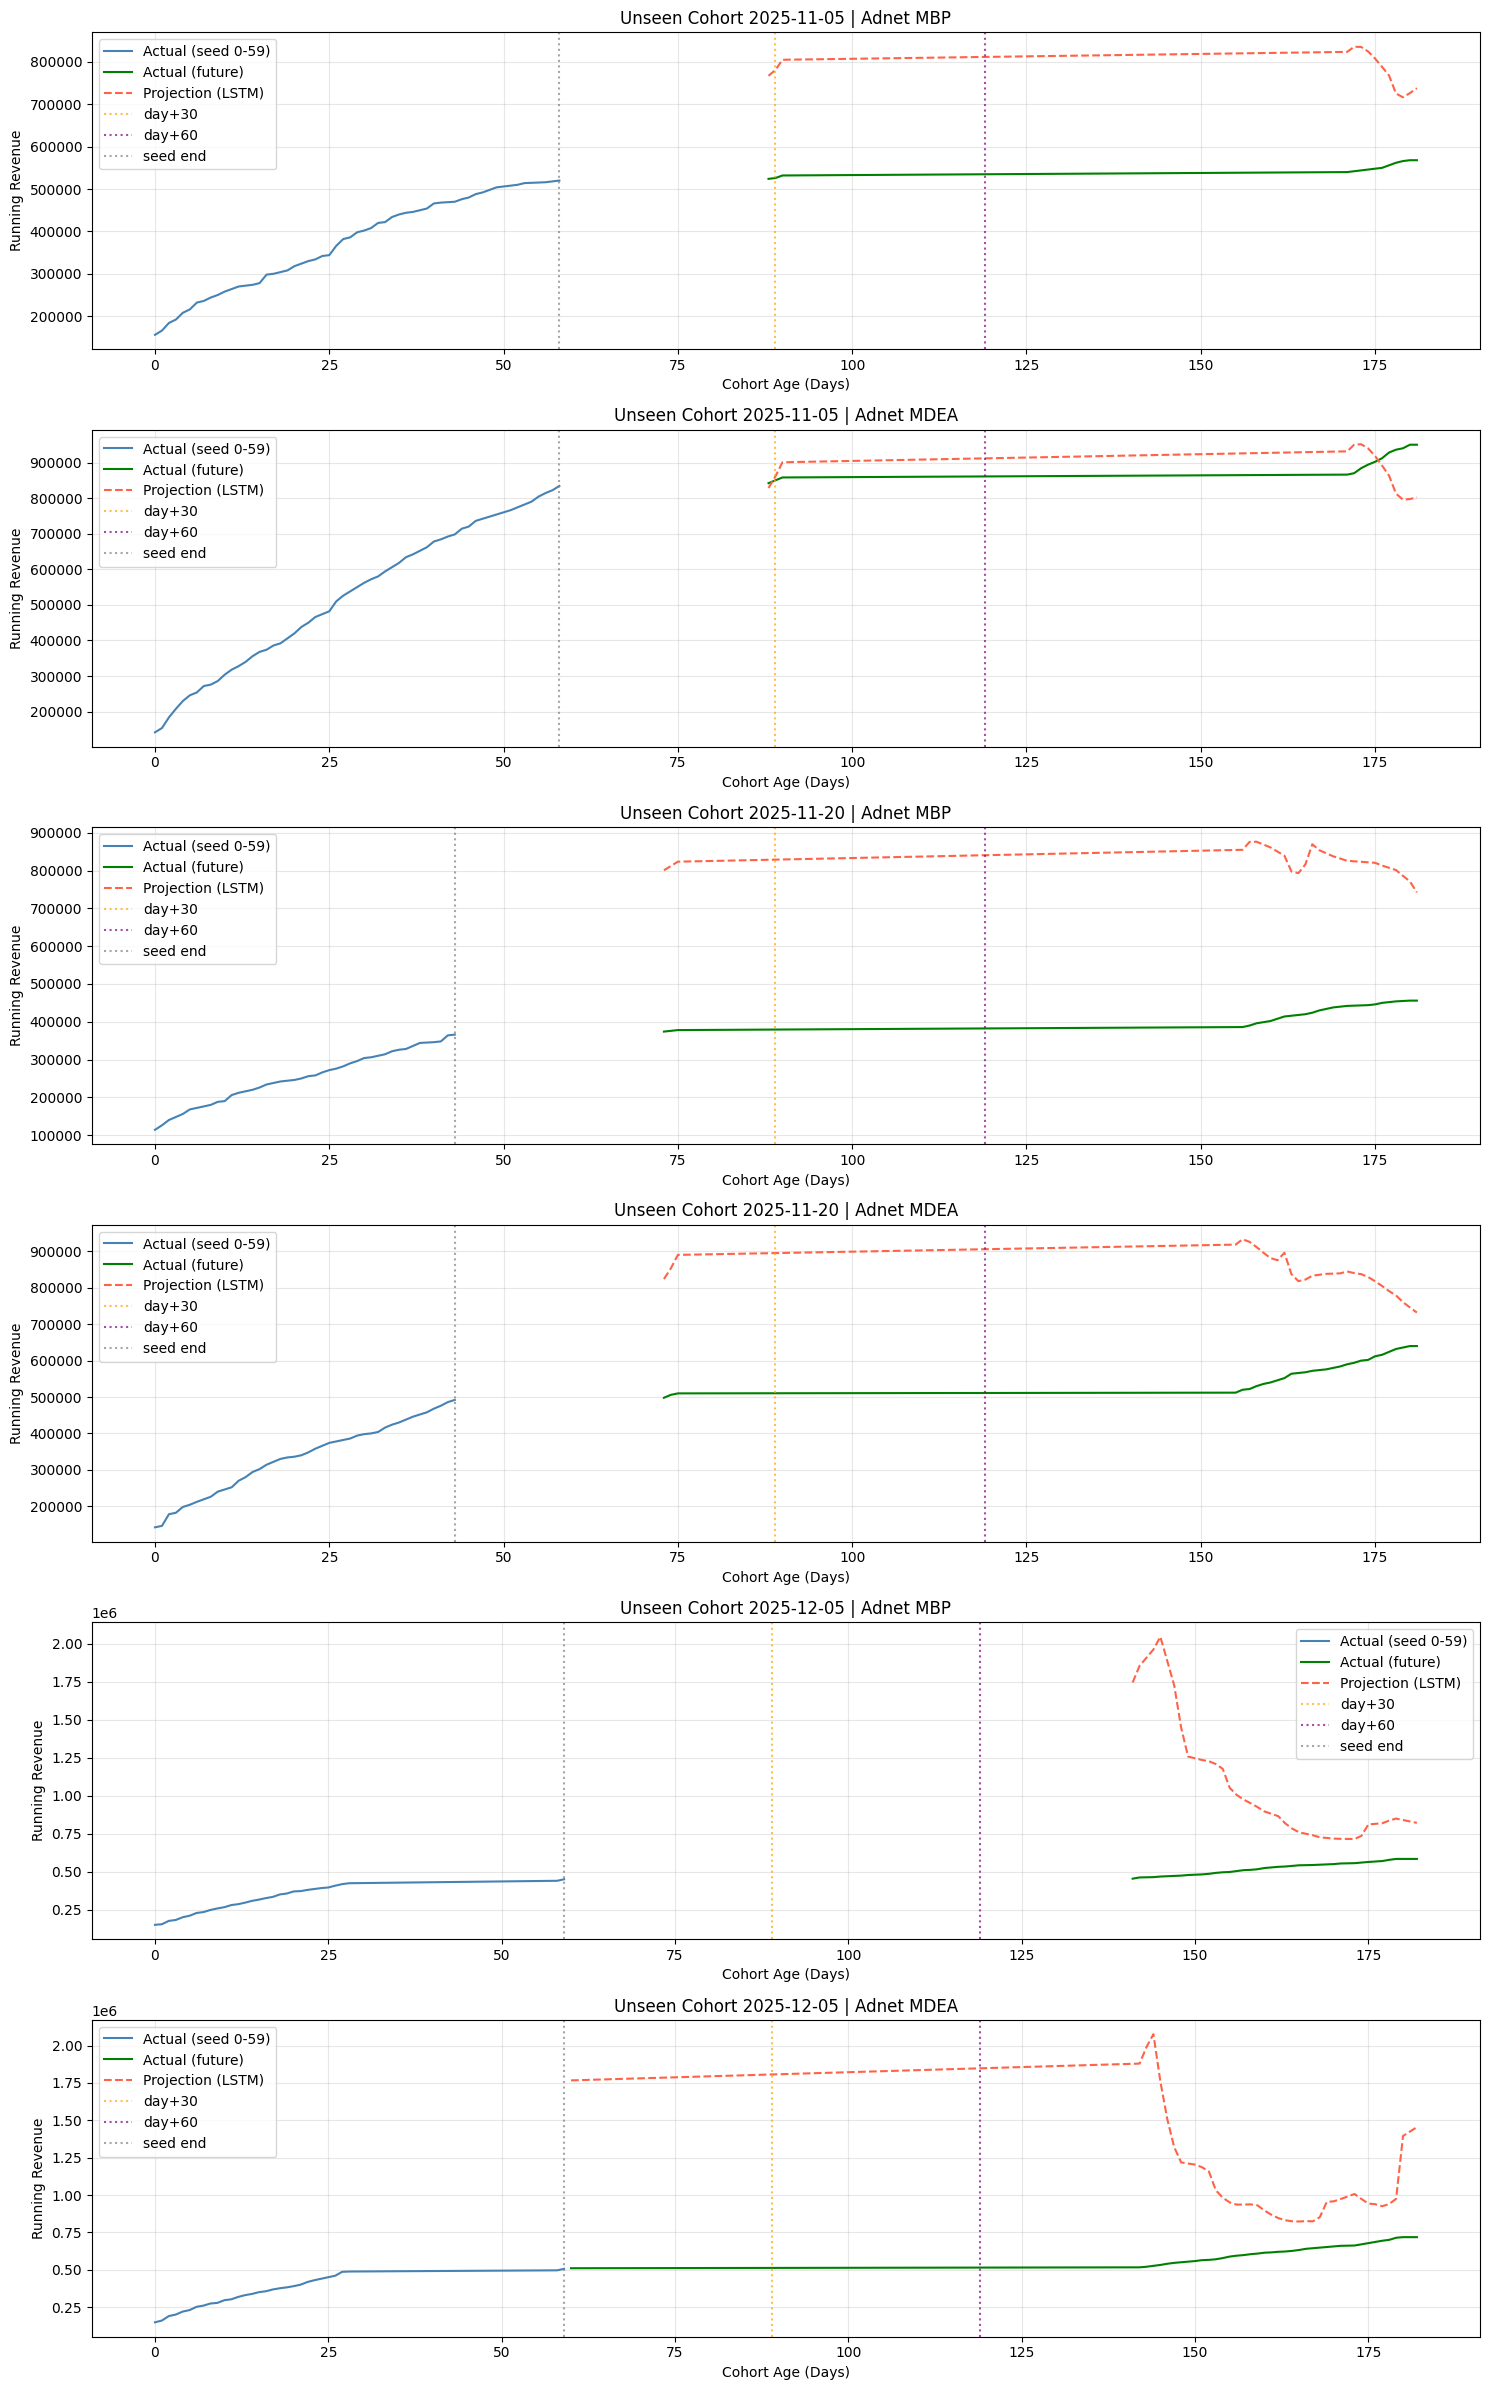

In [712]:
n_cohorts = len(results_unseen)
fig, axes = plt.subplots(n_cohorts, 1, figsize=(15, 4 * n_cohorts))

if n_cohorts == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results_unseen.items()):
    cohort_raw = r['cohort_raw']
    seed_len   = r['seed_len']
    n_steps    = r['n_steps']

    # Get seed_running from RAW (unscaled) data
    seed_mask_viz = cohort_raw['cohort_age'] < seed_len
    seed_running_u = cohort_raw.loc[seed_mask_viz, TARGET].values.astype(float)

    seed_age   = cohort_raw[cohort_raw['cohort_age'] < seed_len]['cohort_age'].values
    future_age = cohort_raw[cohort_raw['cohort_age'] >= seed_len]['cohort_age'].values[:n_steps]
    pred_age   = future_age[:len(r['pred_running'])]

    ax.plot(seed_age,   seed_running_u,    label=f'Actual (seed 0-{seed_len-1})', color='steelblue')
    ax.plot(future_age, r['actual_running'],label='Actual (future)',              color='green')
    ax.plot(pred_age,   r['pred_running'],  label='Projection (LSTM)',            color='tomato', linestyle='--')

    for offset, color in [(30, 'orange'), (60, 'purple')]:
        day = seed_len + offset - 1
        if len(future_age) > 0 and day <= future_age[-1]:
            ax.axvline(x=day, color=color, linestyle=':', alpha=0.7, label=f'day+{offset}')

    if len(seed_age) > 0:
        ax.axvline(x=seed_age[-1], color='gray', linestyle=':', alpha=0.7, label='seed end')

    ax.set_title(f'Unseen Cohort {str(cohort)[:10]} | Adnet {adnet}')
    ax.set_xlabel('Cohort Age (Days)')
    ax.set_ylabel('Running Revenue')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()